In [1]:
# upload kaggle.json to connect to the Kaggle API
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"probono222012","key":"5bc2e318fc091961436c4dff73918e33"}'}

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("done, kaggle api is set up")

done, kaggle api is set up


In [12]:
# grabbing the gene expression dataset from kaggle
!kaggle datasets download -d crawford/gene-expression --force
!unzip -o -q gene-expression.zip -d gene_data
print("downloaded and unzipped")

Dataset URL: https://www.kaggle.com/datasets/crawford/gene-expression
License(s): CC0-1.0
100% 1.41M/1.41M [00:00<00:00, 81.7MB/s]

downloaded and unzipped


In [21]:
!unzip -o -q gene-expression.zip -d gene_data

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [26]:
# load the raw files
train = pd.read_csv("gene_data/data_set_ALL_AML_train.csv")
test = pd.read_csv("gene_data/data_set_ALL_AML_independent.csv")
actual = pd.read_csv("gene_data/actual.csv")

In [27]:
# drop the "call" columns, we only want expression values
train_cols = [c for c in train.columns if "call" not in c.lower()]
test_cols = [c for c in test.columns if "call" not in c.lower()]
train_clean = train[train_cols]
test_clean = test[test_cols]

In [28]:

# genes are rows, patients are columns right now — flip it so patients are rows
train_clean = train_clean.set_index(["Gene Description", "Gene Accession Number"])
test_clean = test_clean.set_index(["Gene Description", "Gene Accession Number"])
train_T = train_clean.T
test_T = test_clean.T

full = pd.concat([train_T, test_T])
full.index = full.index.astype(int)
full = full.sort_index()
full = full.apply(pd.to_numeric)

In [32]:
print(actual.columns.tolist())
print(actual.head())

['cancer']
        cancer
patient       
1          ALL
2          ALL
3          ALL
4          ALL
5          ALL


In [34]:
# make sure patient ids in actual line up with full's index
actual = actual.loc[full.index]

X = full
y = actual["cancer"]

print("shape of X:", X.shape)
print(y.value_counts())

shape of X: (72, 7129)
cancer
ALL    47
AML    25
Name: count, dtype: int64


In [35]:
# scale before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
# way more genes than patients, so reduce dimensions first
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("variance explained:", pca.explained_variance_ratio_.sum())

variance explained: 0.6395859678210006


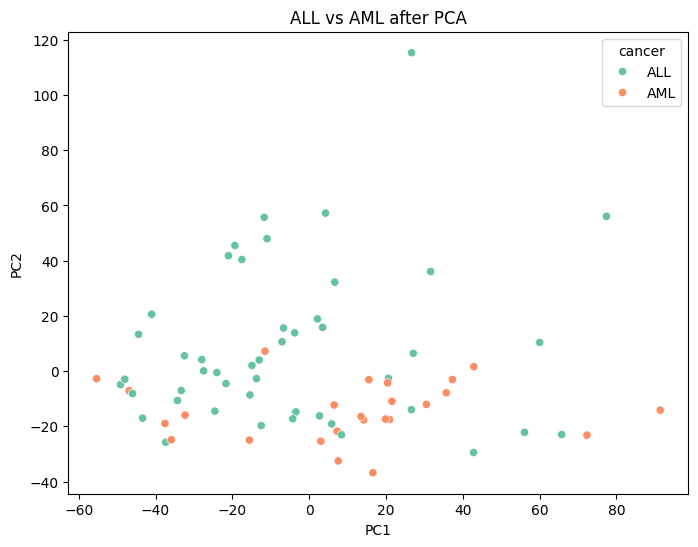

In [37]:
# quick visual to see if ALL and AML separate
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set2')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("ALL vs AML after PCA")
plt.show()

In [38]:
# split and train
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [39]:
y_pred = model.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy: 0.8
              precision    recall  f1-score   support

         ALL       0.82      0.90      0.86        10
         AML       0.75      0.60      0.67         5

    accuracy                           0.80        15
   macro avg       0.78      0.75      0.76        15
weighted avg       0.80      0.80      0.79        15



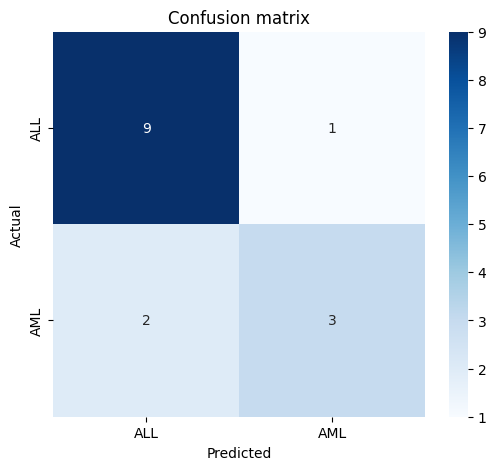

In [40]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [41]:
# which genes matter most
pc1_loadings = pd.Series(pca.components_[0], index=X.columns.get_level_values("Gene Description"))
top_genes = pc1_loadings.abs().sort_values(ascending=False).head(15)
print(top_genes)

Gene Description
HMGI-C                                                                                            0.028786
Branched chain Acyl-CoA Oxidase                                                                   0.028177
ZNF183 gene                                                                                       0.027927
DLG2 Homolog 2 of Drosophila large discs                                                          0.027871
Carboxylesterase (hCE-2) mRNA                                                                     0.027757
CYP2C17 Cytochrome P450; subfamily IIC (mephenytoin 4-hydroxylase); polypeptide 17                0.027681
GB DEF = Unknown protein mRNA; partial cds                                                        0.027490
FACC Fanconi anemia complementation group C                                                       0.027450
REG1A Regenerating islet-derived 1 alpha (pancreatic stone protein; pancreatic thread protein)    0.027434
CDH5 Cadherin 5; VE-